<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Introduction to DEA Coastal Ecosystems</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟢 Beginner</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Runtime: ~10 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b>
<ul style="margin:8px 0 0 0; padding-left:20px;">
<li><a href="https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/">ga_s2_coastalecosystems_cyear_3_v1</a></li>
</ul>
</div>

<!-- Citing - OPTIONAL, delete if not required -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📝 Citation</b><br>
Please use the following citation when reporting results generated using this notebook. 

<i>Krause, C., Dunn, B., Bishop-Taylor, R., Adams, C., Burton, C., Alger, M., Chua, S., Phillips, C., Newey, V., Kouzoubov, K., Leith, A., Ayers, D., Hicks, A., DEA Notebooks contributors 2021. Digital Earth Australia notebooks and tools repository. Geoscience Australia, Canberra. https://doi.org/10.26186/145234</i><br>

</div>

<!-- Important notes - OPTIONAL, delete if not required and use sparingly -->
<div style="margin-bottom:12px; padding:12px; background:rgba(251,191,36,0.15); border:1px solid rgb(251,191,36); border-radius:8px; max-width:85%;">
<b>⚠️ Important</b><br>
Please be aware that this dataset includes a categorical <i>classification</i> layer as well as individual ecosystem <i>probability</i> layers.<br>
We advise that the <i>classification</i> layer be used to examine absolute ecosystem extents from year to year.<br>
To explore changing ecosystems, be aware that this workflow was designed to detect homogenous ecosystems only, but that the <i>probability</i> layers may give some indication of locations with mixed/transitional ecosystem classes.
</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://sandbox.dea.ga.gov.au/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

<!-- - <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div> -->

</div>


## Background
Australia has an extensive coastline with vast extents of coastal ecosystems that include mangrove, saltmarsh and seagrass.
Providing a wide range of ecosystem services which vary from carbon storage to essential habitat and coastal protection, there was a real need to map these ecosystems at the national scale and using a single methodology to support coastal managers, reporting and decision makers.

The DEA Coastal Ecosystems product suite maps the extent of coastal ecosystems within Australia’s coastal zone, with a focus on those situated landward of the low-tide boundary.


## Description
The DEA Coastal Ecosystems product suite maps the extent of coastal ecosystems within Australia’s coastal zone, with a focus on those situated landward of the low-tide boundary.
It was developed using a machine learning workflow that leveraged a methodology used to map shifts in Earths tidal wetlands [Murray et al., 2022](https://www.science.org/doi/10.1126/science.abm9583).
Using Sentinel-2 data and derived datasets, the product suite provides an annual 10 m resolution extent classification layer for four ecosystem classes - mangrove, saltmarsh, intertidal flats and intertidal seagrass - enabling users to better monitor and understand the distribution of these ecosystems at a continental scale. 
The classification layer is supported by individual ecosystem probability layers, to allow a more nuanced interpretation of the modelled ecosystem extents and to provide users flexibilty for tailored mapping approaches. Data is available for the years 2021 and 2022.

A detailed technical description of the product can be found on the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/)

This notebook will:

1. Introduce the five core layers of the product suite
2. Extract some insights through basic analyses, including
    - calculating the ecosystem extents for a given area
    - visualise mixed and transitional ecosystems using a fractional cover approach and
    - empower users to develop their own categorical classification of coastal ecosystems

This notebook is designed to be read fully on the first run-through (from the upper menu, select `Run`, followed by `Run All Cells`).
Following this, editable variables are identified that users can return to and adjust to suit their own needs and analyses.

***

## Load packages
Import Python packages and load functions that are used for the analysis.

In [86]:
import pystac_client
import odc.stac

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray 

import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg

from IPython.display import display
from matplotlib.colors import ListedColormap, BoundaryNorm
from ipywidgets import HBox, VBox, HTML, Image as IPImage, Layout

from dea_tools.plotting import rgb, display_map
from dea_tools.maps import folium_map

# Create mapping function to handle non-sequential categorical data
def remap_dataarray(da, value_to_index):
    """Remap DataArray values to sequential indices"""
    mapped_values = np.full_like(da.values, np.nan, dtype=float)
    for actual_val, index in value_to_index.items():
        mapped_values[da.values == actual_val] = index
    
    # Create new DataArray with same coordinates
    return xr.DataArray(mapped_values, coords=da.coords, dims=da.dims)

## Analysis parameters - STAC

This notebook uses the [Statio Temporal Asset Catalogue (STAC)](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) to discover and load data for this analysis.

STAC metadata has four important components that must be configured to enable data discovery and loading:

- **Catalog**: A structure for organising multiple datasets managed by a given provider. For example, Planetary Computer’s Catalog

- **Collection**: A structure for organising all items in a single dataset. For example, Land Use Land Cover Collection

- **Item**: A single spatio-temporal item, such as one observation in a dataset. For example, Land Use Land Cover Data for Supercell 28R in 2023

- **Asset**: A single data measurement associated with an item, such as a single band. The Land Use Land Cover Dataset has only one asset, called “data”.

We must specify the URL for the catalog we want to search, along with the desired collection (io-lulc-annual-v02) and asset (data). The precise items that we need to load will be returned by a query that we run later.

* `param_name_1`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.
* `param_name_2`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.


### 1. Connect to DEA's STAC API

This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access`.
If launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically.

In [87]:
# # # Configure data access
# # odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# # Connect to STAC API
# catalog = pystac_client.Client.open("https://explorer.dev.dea.ga.gov.au/stac") # PROD "https://explorer.dea.ga.gov.au/stac"

# # Test from DEA STAC guide
# odc.stac.configure_rio(
#     cloud_defaults=True,
#     aws={"aws_unsigned": True},
# )

### 2. Build a data query for your location and date/s of interest

Identify your data search parameters. 
View your area of interest on the interactive map to ensure your coordinates are correct.
Leave the geometry coordinates for Shoalwater Bay, Queensland for your first run-through.

Edit the `geometry` variables to change the analysis location.

In [88]:
# Identify the DEA Coastal Ecosystems product ID
product = ['ga_s2_coastalecosystems_cyear_3_v1']

# Set a start and end date
start_time = '2021-01-01'
end_time = '2022-12-31'

# Set a bounding box
# [xmin, ymin, xmax, ymax] in latitude and longitude
geometry = [150.4, -22.4, 150.8, -22.7]

# Check your geometry before proceeding
display_map(x=(geometry[0],geometry[2]), y=(geometry[1],geometry[3]))

In [89]:
# # Build a query with the parameters above and then explore the DEA STAC catalogue for matching datasets.
# query = catalog.search(
#     bbox=geometry,
#     collections=product,
#     datetime=f"{start_time}/{end_time}",
# )

# # Search the STAC catalog for all items matching the query
# items = list(query.items())
# print(f"Found: {len(items):d} datasets")
# print(f'Available bands: {list(items[0].assets.keys())[:-3]}')

### 3. Load data

Once you have found data to load, use the `odc.stac.load()` function to load them in an `xarray.Dataset` format.

In [90]:
# ds = odc.stac.load(
#     items,
#     bands=["elevation", "elevation_uncertainty","exposure","extents","ta_spread"],#"mangrove_prob","saltmarsh_prob","saltflat_prob","seagrass_prob","qa_count_clear","qa_coastal_connectivity"],
#     crs="utm",
#     resolution=10,
#     # groupby="solar_day",
#     bbox=geometry,
# )

# ds

# Temporary data load from the datacube database

Connect to the Digital Earth Australia datacube and load data from its database

In [91]:
import datacube

dc = datacube.Datacube(env='dev')

Using the search parameters identified previously, build a query and load the DEA Coastal Ecosystems data for your time and location of interest.

In [92]:
# Build a search query using the time and location parameters identified previously
query = {
    "y": (geometry[1],geometry[3]),
    "x": (geometry[0],geometry[2]),
    "time": (start_time, end_time),
}
# Load data
ds = dc.load(product=product,
            **query)

# Drop nodata values
ds_masked = ds.where(ds != 255)
ds_masked['qa_coastal_connectivity'] = ds.qa_coastal_connectivity.where(ds.qa_coastal_connectivity != 65535)

# View data
ds_masked

<xarray.Dataset> Size: 990MB
Dimensions:                  (time: 2, y: 3909, x: 4521)
Coordinates:
  * time                     (time) datetime64[ns] 16B 2021-07-02T11:59:59.99...
  * y                        (y) float64 31kB -2.547e+06 ... -2.586e+06
  * x                        (x) float64 36kB 1.867e+06 1.867e+06 ... 1.912e+06
    spatial_ref              int32 4B 3577
Data variables:
    classification           (time, y, x) float32 141MB nan nan nan ... nan nan
    mangrove_prob            (time, y, x) float32 141MB nan nan nan ... nan nan
    saltmarsh_prob           (time, y, x) float32 141MB nan nan nan ... nan nan
    saltflat_prob            (time, y, x) float32 141MB nan nan nan ... nan nan
    seagrass_prob            (time, y, x) float32 141MB nan nan nan ... nan nan
    qa_count_clear           (time, y, x) float32 141MB 49.0 49.0 ... 45.0 45.0
    qa_coastal_connectivity  (time, y, x) float32 141MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

Note that the data loads as an `xarray.Dataset`.

- The `Dimensions` describe the timesteps and pixel dimensions for your area in general terms
- The `Coordinates` add precise time and location details to your data
- The `Data variables` show you the 7 layers of the DEA Coastal Ecosystems dataset.
    - The `classification` layer is a categorical classifier of coastal ecosystem types. Classes: 2 = intertidal; 3 = mangrove; 4 = saltmarsh; 5 = intertidal seagrass.
    - The four `x_prob` layers are probability distributions for the named coastal ecosystem types
    - Two `qa_x` layers are provided for quality assurance

Detailed descriptions of the data layers can be found in the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/?tab=description#technical-information)

## View the dataset layers

First, we will set up a colour map to display the `classification` data

In [93]:
# Set up the colormap for the classification
values = [2, 3, 4, 5]
colours = ['#94410d', '#29df3a', '#dbe436', '#0d834e'] #QGIS colours
labels = ['Intertidal', 'Mangroves', 'Saltmarsh', 'Intertidal\nSeagrass']

# Create a custom colormap
cmap = mcolors.ListedColormap(colours)

# Define boundaries for discrete values
bounds = [v - 0.5 for v in values] + [values[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

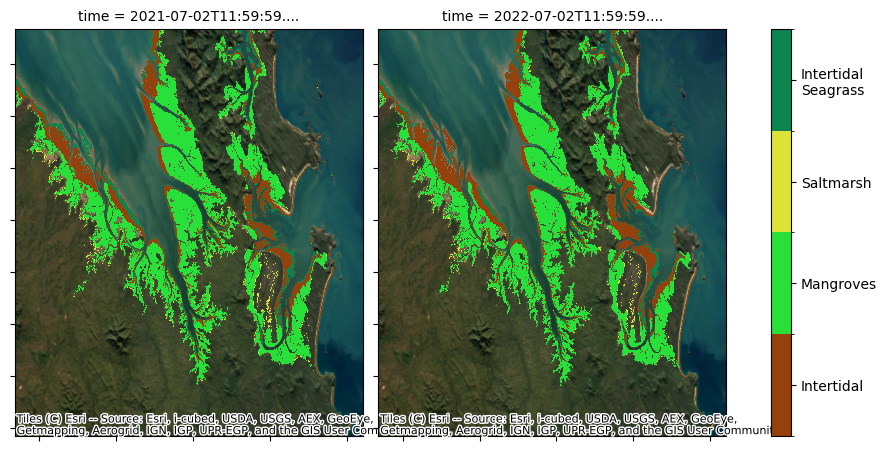

In [94]:
# Plot the classification layer for both years side by side
fig = ds_masked.classification.plot(col='time', 
                                    figsize=(10,5),
                                    cmap=cmap,
                                    norm=norm,
                                    add_colorbar=False,
                                   )
# Add a basemap and clean up axis labels
for ax in fig.axs.flat:
    ctx.add_basemap(
    ax=ax,
    crs=ds_masked.rio.crs,
    source=ctx.providers.Esri.WorldImagery
    )
    ax.label_outer()
    ax.set_xticklabels(labels=[])
    ax.set_yticklabels(labels=[])
    ax.set_xlabel("")
    ax.set_ylabel("")

# Add the custom colormap
cbar = plt.colorbar(
    fig.axs.flat[0].collections[0],  
    ax=fig.axs.ravel().tolist(), 
    ticks=values,
)
cbar.ax.set_yticklabels(labels)
# Show
plt.show()

DEA Coastal Ecosystems has been produced for two years: 2021 and 2022.
Differences between the two years are subtle but can often be distinguished through differences in the seagrass class.

This categorical classification has been determined using the following probability layers as well as some context related masking.
The classification methodology is discussed in detail in the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/).

Briefly:
- mangrove and saltmarsh ecosystems are classified if a pixel has >= 50 % probability of belonging to the class
- intertidal ecosystems have been mapped previously with a high level of confidence in the [DEA Intertidal](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/) product suite. These same extents are used in the DEA Coastal Ecosystems classification layer
- intertidal seagrass was classified if located within the intertidal extent and had a probability of >= 70 %.

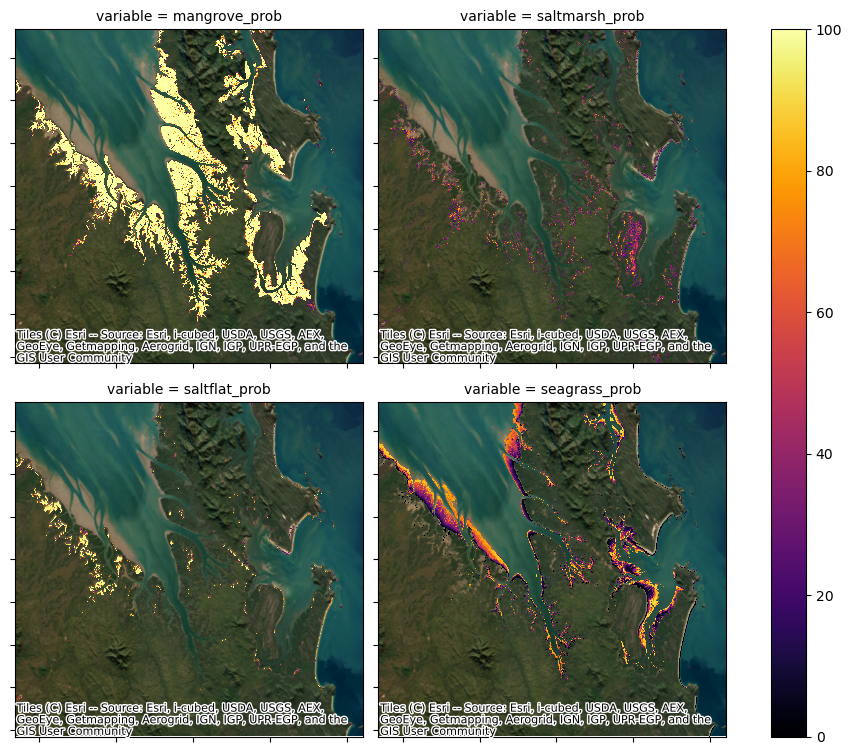

In [95]:
# Plot the probability layers for one year: 2021

fig = ds_masked.isel(time=0)[["mangrove_prob",
                     "saltmarsh_prob",
                     "saltflat_prob",
                     "seagrass_prob"]].to_array().plot(col="variable", col_wrap=2, figsize=(10,8), cmap='inferno')
# Add basemap and format axes of each subplot
for ax in fig.axs.flat:
    ctx.add_basemap(
    ax=ax,
    crs=ds_masked.rio.crs,
    source=ctx.providers.Esri.WorldImagery
    )
    ax.label_outer()
    ax.set_xticklabels(labels="")
    ax.set_yticklabels(labels="")
    ax.set_xlabel("")
    ax.set_ylabel("")

The four classes in the categorical `classification` map include mangrove, saltmarsh, intertidal flats and intertidal seagrass. However, the four probability layers include mangrove, saltmarsh, saltflat and intertidal seagrass. Briefly, the reasoning for these class differences include:
- Intertidal flats have been mapped previously with a high level of confidence for the period of interest in the [DEA Intertidal](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/) product suite. These same extents are used in the DEA Coastal Ecosystems classification layer and were also used to limit the extents of the modelled intertidal seagrass. As the intertidal flats are a known extent, we did not publish a probability layer for them.
- The modelling used to generate the DEA Coastal Ecosystems product suite produced a probability extent for saltflat coastal ecosystems. The accuracy of saltflat modelling in the southern half of Australia was lower than our tolerance and the class was excluded from the continental `classification` map. In northern parts of Australia, the saltflat modelling is very good and the probabilities are included for use at a users own discretion.

><b>For a complete discussion regarding the decisions for the inclusion/exclusion of classes in the DEA Coastal Ecosystem product suite, please see the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/)</b>

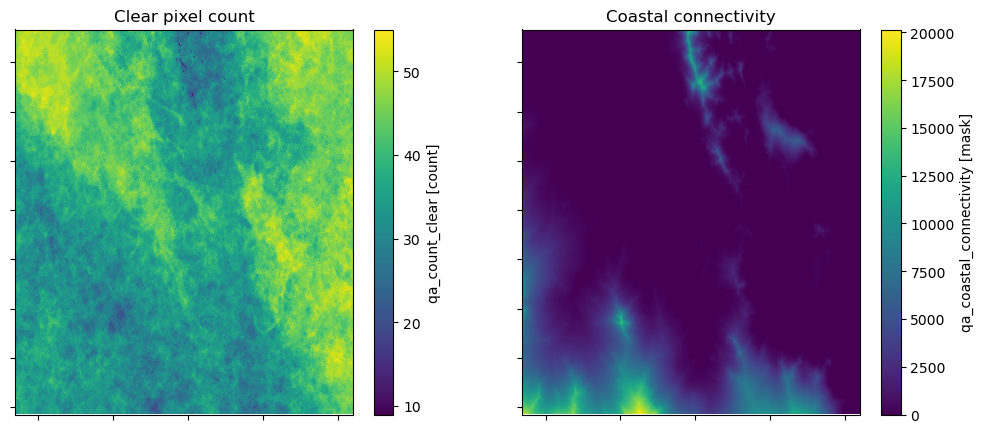

In [96]:
# Plot the quality-assurance layers for one year: 2021

fig, axs = plt.subplots(1,2, figsize=(12,5))
ds_masked.isel(time=0).qa_count_clear.plot(ax=axs[0])
ds_masked.isel(time=0).qa_coastal_connectivity.plot(ax=axs[1])
axs[0].set_title('Clear pixel count')
axs[1].set_title('Coastal connectivity')

# for ax in fig.axes.flat:
for ax in range(0,2):
    axs[ax].label_outer()
    axs[ax].set_xticklabels(labels="")
    axs[ax].set_yticklabels(labels="")
    axs[ax].set_xlabel("")
    axs[ax].set_ylabel("")

Annual modelling for DEA Coastal Ecosystems is completed using a single year of Sentinel-2 satellite observations.

Pixels with fewer than 10 clear and valid observations (geometrically accurate, cloud and glint-free) are excluded from the analysis.
A `clear pixel count` layer is included with the product to support users to interpret the data.

A `coastal connectivity` model was developed to support coastal ecosystem analysis in this product and the [DEA Intertidal](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/) product suite.
The model is a dimensionless representation of how connected pixels are to those at intertidal elevations.
The cost-distance weighted model assesses elevation and distance to represent highly connected coastal locations with low values.
Less connected areas that are either elevated or separated by distance are penalised with high values in the model.
The model is discussed further in the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/).
It is included as part of the product suite to support interpretation.

## Calculate ecosystem extents

DEA Coastal Ecosystems `classification` data can be used to calculate the extent of coastal ecosystems for a given area.
This analysis will compare the mapped extents for both years of the dataset and return the extent in km^2.

In [97]:
# Define a dictionary to add interpretable labels to the data
key = {'0':'2021', 
        '1':'2022',
        '2':'intertidal',
        '3':'mangrove',
        '4':'saltmarsh',
        '5':'seagrass'}

# Summarise the ecosystem extents
px_count=[]
for year in range(0,2):
    for ecosystem in range(2,6):
        count = ds_masked['classification'].isel(time=year).where(ds_masked['classification'].isel(time=year)==ecosystem).count()
        px_count.append((key[str(year)], key[str(ecosystem)], count.values))   

# Translate to a dataframe
table = pd.DataFrame(px_count, columns=['col', 'row', 'value']).assign(
    value=lambda x: x['value'].apply(lambda y: y.item())
    ).pivot(index='row', columns='col', values='value')

# Calculate the extents in km2
table = np.round((table * 100)/1000000,2)

# Remove axis labels
table.index.name = None
table.columns.name = None

# Display the table
table


,2021,2022
intertidal,73.44,81.92
mangrove,197.37,200.01
saltmarsh,7.24,5.15
seagrass,29.18,20.96


## Coastal Fractional Cover

The DEA Coastal Ecosystems `classification` layer identifies pixels with a high likelihood of belonging to the classified class.
However, the `probability` layers demonstrate that there is a spectrum of probabilities for these ecosystems and that they often overlap.

A fractional cover model uses colour to identify these pixels where more than 1 class has a modelled probability.

The model maps each of the mangrove, saltmarsh and saltflat probability layers into one of the red, green, or blue channels of a multi-band image.
The legend shows the relative percentage of each class that is represented in a pixel.

Fractional coastal cover may be useful to inform on ecosystem dynamics and the selection of probability thresholds for the determination of customised classifications (see the next section below).

Firstly, load a new data sample. 
Here, we've used the McArthur River in the Northern Territory.
Set your own `geometry` coordinates to try a different location.

In [98]:
# Set a bounding box
# [xmin, ymin, xmax, ymax] in latitude and longitude
geometry = [136.55, -15.8, 136.72, -15.92]

# Check your geometry before proceeding
display_map(x=(geometry[0],geometry[2]), y=(geometry[1],geometry[3]))

In [99]:
# Load data
query = {
    "y": (geometry[1],geometry[3]),
    "x": (geometry[0],geometry[2]),
    "time": (start_time, end_time),
}

ds = dc.load(product=product,
            **query)
# Drop nodata values
ds_masked = ds.where(ds != 255)
ds_masked['qa_coastal_connectivity'] = ds.qa_coastal_connectivity.where(ds.qa_coastal_connectivity != 65535)
# View
ds_masked

<xarray.Dataset> Size: 146MB
Dimensions:                  (time: 2, y: 1387, x: 1880)
Coordinates:
  * time                     (time) datetime64[ns] 16B 2021-07-02T11:59:59.99...
  * y                        (y) float64 11kB -1.688e+06 ... -1.702e+06
  * x                        (x) float64 15kB 4.899e+05 4.899e+05 ... 5.087e+05
    spatial_ref              int32 4B 3577
Data variables:
    classification           (time, y, x) float32 21MB nan nan nan ... nan nan
    mangrove_prob            (time, y, x) float32 21MB nan nan nan ... nan nan
    saltmarsh_prob           (time, y, x) float32 21MB nan nan nan ... nan nan
    saltflat_prob            (time, y, x) float32 21MB 85.0 87.0 ... nan nan
    seagrass_prob            (time, y, x) float32 21MB nan nan nan ... nan nan
    qa_count_clear           (time, y, x) float32 21MB 51.0 51.0 ... 55.0 55.0
    qa_coastal_connectivity  (time, y, x) float32 21MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [105]:
# Prepare the 2021 probability data
# Replace Nodata values with 0 % probability
ds_nonan = ds_masked[['mangrove_prob','saltmarsh_prob','saltflat_prob']]
ds_nonan = ds_nonan.fillna(0)

# Drop pixels where all classes are nan
ds_sum = ds_masked[['mangrove_prob','saltmarsh_prob','saltflat_prob']].isel(time=0).to_array().sum(dim='variable')
ds_nonan = ds_nonan.where(ds_sum>0)

# Configure the colour style
rgb_ows_cfg = {
    "components": {
        "red": {"mangrove_prob": 100.0},
        "green": {"saltmarsh_prob": 100.0},
        "blue": {"saltflat_prob": 100.0},
    },
    "scale_range": (20, 100),#(50, 3000), 
}

# Configure the ESRI basemap settings
tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'
attr = 'Esri'

# Create folium map and convert to HTML widget
m = folium_map(ds_nonan.isel(time=0), ows_style_config=rgb_ows_cfg, zoom_start=12, tiles=tiles, attr=attr)
folium_widget = HTML(value=m._repr_html_(), layout=Layout(width='60%'))

# Load the legend (png) as ipywidgets Image
with open('coastal_ecosystem_fractional_cover_legend.png', 'rb') as f:
    img_widget = IPImage(value=f.read(), format='png', layout=Layout(width='40%'))

# Create overall title
main_title = HTML(value='<h2 style="text-align: center; font-weight: bold; margin-bottom: 15px;">Coastal Ecosystems Fractional Cover (2021)</h2>')

# Create HBox with both components
content = HBox([folium_widget, img_widget])

# Wrap title and content in VBox
display(VBox([main_title, content]))

/env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Use your mouse wheel or the +/- icons to interactively zoom around the coastal fractional cover dataset on the left hand side.

High probability mangrove classes are shown in red.
High probability saltmarsh classes are shown in green.
High probability saltflat classes are shown in blue.

50 % / 50 % saltflat and mangrove areas are shown in magenta.
50 % / 50 % mangrove and saltmarsh areas are shown in yellow.
50 % / 50 % saltmarsh and saltflat areas are shown in cyan.

Representing the coastal classes in this way demonstrates the difficulty in assigning exact extents to coastal ecosystems.

In the next section, you can use the probability layers to customise your own `classification` layer.
Use the fractional cover distributions to inform your choice of probability threshold.

## Create a custom classification

The DEA Coastal Ecosystems `classification` layer uses a series of thresholds and masks to create a meaningful continental and simultaneous classification of coastal ecosystems.

For local investigations, and/or to include a saltflat class, it may be beneficial to experiment with a custom classification, using the probability layers.

In this example, experiment with setting the `min_prob` value.
It is currently set to `min_prob = 40`. 
You might like to try `min_prob = 75` for example.
This will set the minimum probability value per class for consideration in the classification.

The DEA Coastal Ecosystems `classification` layer uses a separate threshold for intertidal seagrass (70 %) compared to the other classes (50 %).
If you feel comfortable experimenting, try setting different probability thresholds for the different classes (replacing the `min_prob` with an explicit value of your choice e.g. 65 for 65 %)

In the cell below,
- you will identify your probability threshold/s

Then the code will:
- prepare and combine the class_probability layers
- create the classified layer by taking the class with the highest probability per pixel
- create a sequential colourmap to plot the classification against (and ordering the data sequentially if required)
- mapping your classification side by side with the DEA Coastal Ecosystems `classification` for comparison with ESRI WorldImagery beneath

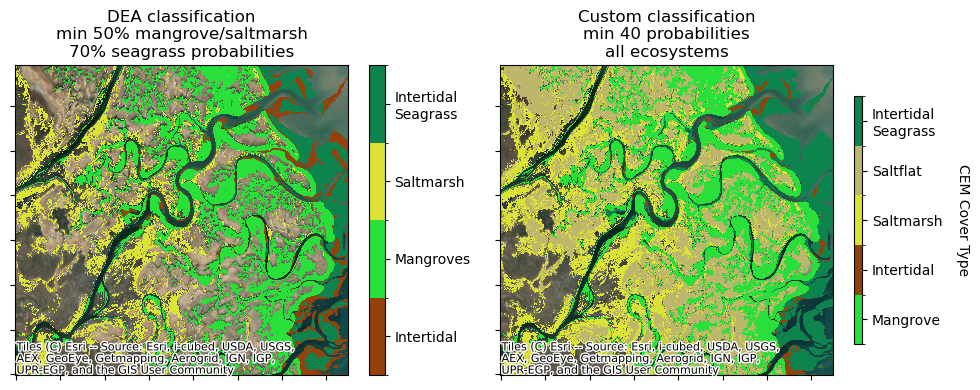

In [106]:
# What is the minimum probability value for inclusion in the classification?
# Adjust this value only to apply the threshold to all classes in the classification.
min_prob = 40

# Load intertidal extent
intertidal = dc.load(product='ga_s2ls_intertidal_cyear_3',
                     measurements = 'extents',
                    **query)
intertidal = intertidal.extents.isel(time=0).where(intertidal.extents.isel(time=0)==3)

# Prepare the input layers (customise the class thresholds by replacing min_prob)
# Mangrove
mangrove = ds_masked.isel(time=0).mangrove_prob.where(ds_masked.isel(time=0).mangrove_prob >= min_prob)
# Saltmarsh
saltmarsh = ds_masked.isel(time=0).saltmarsh_prob.where(ds_masked.isel(time=0).saltmarsh_prob >= min_prob)
# Saltflat
saltflat = ds_masked.isel(time=0).saltflat_prob.where(ds_masked.isel(time=0).saltflat_prob >= min_prob)
# Seagrass
seagrass = ds_masked.isel(time=0).seagrass_prob.where(ds_masked.isel(time=0).seagrass_prob >= min_prob)
# Intertidal
intertidal = intertidal.where(intertidal.isnull(), min_prob)

# Combine into a single dataset
dss = xr.Dataset()
dss['mangrove']=mangrove
dss['saltmarsh']=saltmarsh
dss['saltflat']=saltflat
dss['seagrass']=seagrass
dss['intertidal']=intertidal

# Sum dataset to remove nans later
dss_sum = dss.to_array().sum(dim='variable')

# Define a dictionary to add interpretable labels to the data
key = {'mangrove':3,
       'intertidal':2,
       'saltmarsh':4,
       'saltflat':6,
       'seagrass':5,
       }

# Relabel string names with integer labels  
data_vars = list(dss.data_vars.keys())
mapped_values = [key[var] for var in data_vars]

# Create a DataArray to store the classification
mapping_da = xr.DataArray(mapped_values, dims=['variable'])

# Classify the probability layers, taking argmax and directly index into the new DataArray
stacked = xr.concat([dss[var] for var in data_vars], dim='variable')

try:
    max_indices = stacked.argmax(dim='variable', skipna=True)
except ValueError:
    max_indices = stacked.fillna(-999).argmax(dim='variable')
    
max_mapped = mapping_da[max_indices]

# Create a mapping from indices to variable names
var_names = xr.DataArray(data_vars, dims=['variable'])
max_source_names = var_names[max_indices]

# Remove nan values
max_mapped = max_mapped.where(dss_sum!=0)

# Add classified layer and classified layer names to master dataset
dss['max'] = max_mapped
dss['max_name'] = max_source_names

# Dictionary to map values and plot colours against
Classified_labels = {
                2:['Intertidal', '#94410d'],
                3:['Mangrove','#29df3a'],
                4:['Saltmarsh','#dbe436'],
                5:['Intertidal\nSeagrass','#0d834e'],
                6:['Saltflat','darkkhaki'],
                } # Set as transparent

# Get unique values to ensure consistent mapping
unique_values = key.values()

# Prepare colorbar
categories = []
colours = []
for val in unique_values:
    categories.append(Classified_L1_labels[val][0])
    colours.append(Classified_L1_labels[val][1])

# Create a discrete colormap
cmap1 = ListedColormap(colours[:len(unique_values)])

# Create boundaries for the colormap
bounds1 = np.arange(len(unique_values) + 1) - 0.5
norm1 = BoundaryNorm(bounds1, cmap1.N)

# Create new xarray DataArrays with mapped values for use in `remap_dataarray` function
value_to_index = {val: i for i, val in enumerate(unique_values)}

# Remap non-sequential categories as sequential
reclassified = remap_dataarray(dss['max'], value_to_index)

# Plot using xarray over Esri WorldImagery basemap
fig, ax = plt.subplots(1,2, figsize=(10, 4))

im1 = reclassified.plot(ax=ax[1],cmap=cmap1, norm=norm1, add_colorbar=False)
ax[1].set_title(f'Custom classification\nmin {min_prob} probabilities\nall ecosystems')

im0 = ds_masked['classification'].isel(time=0).plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title('DEA classification\nmin 50% mangrove/saltmarsh\n70% seagrass probabilities')

# Add shared colorbar using the returned image object
cbar = plt.colorbar(im1,  
                    ticks=np.arange(len(unique_values)),
                    shrink=0.8, aspect=30)
cbar.set_ticklabels(categories[:len(unique_values)])
cbar.set_label('CEM Cover Type', rotation=270, labelpad=20)

# Add custom colorbar 
cbar = plt.colorbar(im0,
    # fig.axs.flat[0].collections[0],  
    ax=ax[0], 
    ticks=values,
)
cbar.ax.set_yticklabels(labels)

# format plots and add basemap
for axis in ax:
    ctx.add_basemap(
            ax=axis,
            crs=reclassified.rio.crs,
            source=ctx.providers.Esri.WorldImagery)
    axis.label_outer()
    axis.set_xticklabels(labels="")
    axis.set_yticklabels(labels="")
    axis.set_xlabel("")
    axis.set_ylabel("")

plt.tight_layout()
plt.show()

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [104]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-11-27'